# 02 — PINN for PDE (Heat Equation)

**Module 3 · Week 6 · Nguyễn Như Thịnh**

This notebook covers:
- Extending PINN from ODE to PDE
- Spatiotemporal input `(x, t)`
- Computing partial derivatives `u_t`, `u_x`, `u_xx`
- Enforcing IC and BC
- Comparing with analytic solution via heatmap

**Target PDE:** 1D Heat Equation
```
∂u/∂t = α · ∂²u/∂x²,   x ∈ [0,1],   t ∈ [0,1]
BC:  u(0,t) = 0,   u(1,t) = 0
IC:  u(x,0) = sin(πx)
Analytic: u(x,t) = sin(πx) · exp(-α·π²·t),   α = 0.01
```

---

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
alpha = 0.01  # thermal diffusivity
print(f'Device: {device}')

Device: cuda


## 1. Analytic Solution (Reference)

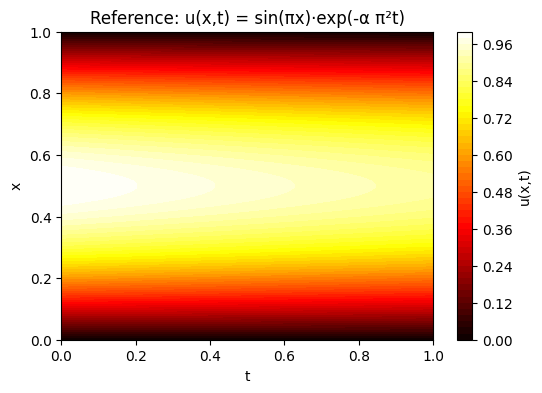

In [ ]:
def analytic_solution(x, t, alpha):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

# Visualize on a grid
x_grid = np.linspace(0, 1, 100)
t_grid = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_grid, t_grid)
U_ref = analytic_solution(X, T, alpha)

plt.figure(figsize=(6, 4))
plt.contourf(T, X, U_ref, levels=50, cmap='hot')
plt.colorbar(label='u(x,t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Reference: u(x,t) = sin(πx)·exp(-α π²t)')
plt.show()

## 2. Define PINN

In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden: int = 64, n_layers: int = 4):
        super().__init__()
        # Input: 2 (x, t)
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden, hidden), nn.Tanh()])
        # Output: 1 (u(x,t))
        layers.append(nn.Linear(hidden, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, xt):
        return self.model(xt)

model = PINN().to(device)

## 3. Sample Training Points

In [ ]:
N_COLLOC = 2000  # interior collocation points
N_BC = 200       # boundary condition points (each boundary)
N_IC = 200       # initial condition points

# Interior: x in (0,1), t in (0,1)
x_c = torch.rand(N_COLLOC, 1)
t_c = torch.rand(N_COLLOC, 1)
xt_colloc = torch.cat([x_c, t_c], dim=1).to(device).requires_grad_(True)

# BC: x=0 and x=1 for t in [0,1]
t_bc = torch.rand(N_BC, 1)
xt_bc0 = torch.cat([torch.zeros(N_BC, 1), t_bc], dim=1).to(device)  # x=0
xt_bc1 = torch.cat([torch.ones(N_BC, 1), t_bc], dim=1).to(device)   # x=1

# IC: t=0, u=sin(pi*x)
x_ic = torch.rand(N_IC, 1)
xt_ic = torch.cat([x_ic, torch.zeros(N_IC, 1)], dim=1).to(device)
u_ic = torch.sin(np.pi * x_ic).to(device)

print(f'Collocation: {xt_colloc.shape}')
print(f'BC (x=0): {xt_bc0.shape}')
print(f'IC: {xt_ic.shape}')

Collocation: torch.Size([2000, 2])
BC (x=0): torch.Size([200, 2])
IC: torch.Size([200, 2])


## 4. PDE Residual

In [ ]:
def pde_residual(model, xt, alpha):
    """Compute heat equation residual: u_t - alpha * u_xx = 0."""
    u = model(xt)

    ## Đạo hàm bậc 1 của u theo tensor xt (chứa cả x và t)
    grads = torch.autograd.grad(
        u, xt,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    # xt[:, 0] là x, xt[:, 1] là t
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    # Đạo hàm bậc 2 của u theo x (tính đạo hàm của u_x theo xt)
    grads_x = torch.autograd.grad(
        u_x, xt,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_xx = grads_x[:, 0:1] # Chỉ lấy cột tương ứng với x

    # Phương trình truyền nhiệt: u_t = alpha * u_xx => u_t - alpha * u_xx = 0
    residual = u_t - alpha * u_xx
    return residual

## 5. Training Loop

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_STEPS = 20000
W_PDE = 1.0
W_BC = 10.0
W_IC = 10.0

loss_history = { 'total': [], 'pde': [], 'bc': [], 'ic': []}

for step in range(N_STEPS):
    optimizer.zero_grad()

    # 1. PDE residual loss tại các điểm collocation (điểm bên trong)
    res = pde_residual(model, xt_colloc, alpha)
    loss_pde = torch.mean(res**2)

    # 2. BC loss: model(xt_bc0) = 0 và model(xt_bc1) = 0
    u_pred_bc0 = model(xt_bc0)
    u_pred_bc1 = model(xt_bc1)
    loss_bc = torch.mean(u_pred_bc0**2) + torch.mean(u_pred_bc1**2)

    # 3. IC loss: Khớp với điều kiện ban đầu
    u_pred_ic = model(xt_ic)
    loss_ic = torch.nn.functional.mse_loss(u_pred_ic, u_ic)

    # Tổng hợp loss
    total_loss = W_PDE * loss_pde + W_BC * loss_bc + W_IC * loss_ic

    total_loss.backward()
    optimizer.step()

    # Lưu lịch sử
    loss_history['total'].append(total_loss.item())
    loss_history['pde'].append(loss_pde.item())
    loss_history['bc'].append(loss_bc.item())
    loss_history['ic'].append(loss_ic.item())

    if (step + 1) % 2000 == 0:
        print(f'Step {step+1}/{N_STEPS}  Loss: {loss_history['total'][-1]:.6f}')

Step 2000/20000  Loss: 0.000475
Step 4000/20000  Loss: 0.000115
Step 6000/20000  Loss: 0.000187
Step 8000/20000  Loss: 0.000108
Step 10000/20000  Loss: 0.000066
Step 12000/20000  Loss: 0.000033
Step 14000/20000  Loss: 0.000047
Step 16000/20000  Loss: 0.000088
Step 18000/20000  Loss: 0.000305
Step 20000/20000  Loss: 0.001782


## 6. Evaluate: Heatmap Comparison

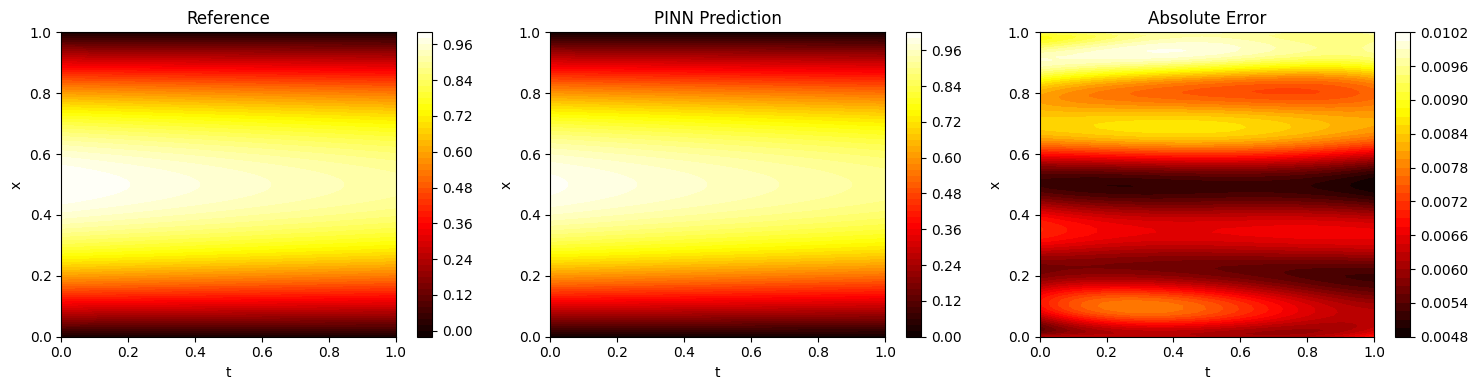

Max absolute error: 0.0101
Mean absolute error: 0.0071


In [ ]:
x_eval = torch.linspace(0, 1, 100)
t_eval = torch.linspace(0, 1, 100)
X_ev, T_ev = torch.meshgrid(x_eval, t_eval, indexing='xy')
xt_eval = torch.stack([X_ev.flatten(), T_ev.flatten()], dim=1).to(device)

with torch.no_grad():
    U_pred = model(xt_eval).cpu().numpy().reshape(100, 100)

U_ref_torch = analytic_solution(X_ev.numpy(), T_ev.numpy(), alpha)
error = np.abs(U_pred - U_ref_torch)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
    [U_ref_torch, U_pred, error],
    ['Reference', 'PINN Prediction', 'Absolute Error']):
    im = ax.contourf(T_ev.numpy(), X_ev.numpy(), data, levels=50, cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_ylabel('x')
    ax.set_xlabel('t')
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(f'Max absolute error: {error.max():.4f}')
print(f'Mean absolute error: {error.mean():.4f}')

## 7. Collocation Point Experiment

*(Complete as part of Week 6 assignment)*

Rerun with `N_COLLOC ∈ [100, 500, 2000, 5000]` and record:

| N_COLLOC | Final PDE loss | Max absolute error |
|----------|---------------|--------------------|
| 100 | 0.0014 |  0.0032 |
| 500 | 0.0018 |  0.0006 |
| 2000 | 0.0071 |  0.0101 |
| 5000 | 0.0010 |  0.0024 |

5000

Max absolute error: 0.0024

Mean absolute error: 0.0010

2000

Max absolute error: 0.0101

Mean absolute error: 0.0071